<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>Análise de Dados</b></CENTER><br/>
        <CENTER><b>WORKFLOW DA AOP2</b></CENTER><br/>

NOME COMPLETO: Patrícia Garcia Vascoselos Matrícula: 202526109

LINK PARA SEU PRÓPRIO COLAB: [Aqui]()

# **Cenário Fictício**:

<center>

**Quanto custa um Diamante ?**

<center>

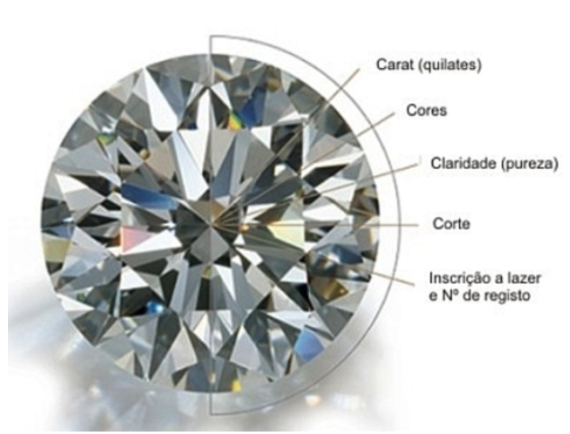

#OBJETIVO:

Determinar qual é a Média Amostral do preço (COLUNA: **PRICE (US$)**) dos Diamantes:
*   Geral ?
*   Por CUT ? Low ? High ?
*   Por COLOR ?
*   Por CLARITY ?
* Por qual análise?
* ... Você vai justificar sua escolha

Para isso, você deve fazer as Atividades abaixo:
* A1: Estatística Descritiva / Gráfica
* A2: Análise de Outliers
* A3: Análise de Reamostragem

# BIBLIOTECAS E FUNÇÕES E CÓDIGOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats

Link do TABLE (download): [Aqui!](https://drive.google.com/file/d/1MBdPEI3no2_CfkxQyff84fFftd9Q0pYs/view?usp=sharing)

In [2]:
# load do table
table = pd.read_csv('table.csv', index_col=0)

In [3]:
table.head(7)

,CARAT,CUT,COLOR,CLARITY,DEPTH,TABLE,X,Y,Z,XYZ,PRICE (US$)
REGISTRO,,,,,,,,,,,
269956,2.120540,Low Quality,H,VVS2,61.4,60.3,4.45,5.49,3.82,93.324510,5121.0
41597,1.827078,High Quality,H,VS2,60.5,56.3,6.15,3.99,3.05,74.842425,8784.0
439877,2.742455,Low Quality,E,VS1,62.2,57.9,5.62,6.66,3.80,142.230960,5836.0
257633,2.531785,Low Quality,I,SI1,58.6,55.4,6.04,8.28,2.48,124.027776,5592.0
112659,2.796243,Low Quality,G,SI1,59.8,55.2,4.56,7.87,4.10,147.137520,5899.0
306300,1.984097,Low Quality,G,VS2,66.2,56.7,5.91,4.39,3.26,84.580374,4966.0
361603,2.941314,Low Quality,G,VVS1,66.1,53.1,7.45,5.65,3.83,161.214275,6067.0


In [4]:
table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 269956 to 324197
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CARAT        200000 non-null  float64
 1   CUT          200000 non-null  object 
 2   COLOR        200000 non-null  object 
 3   CLARITY      200000 non-null  object 
 4   DEPTH        200000 non-null  float64
 5   TABLE        200000 non-null  float64
 6   X            200000 non-null  float64
 7   Y            200000 non-null  float64
 8   Z            200000 non-null  float64
 9   XYZ          200000 non-null  float64
 10  PRICE (US$)  200000 non-null  float64
dtypes: float64(8), object(3)
memory usage: 18.3+ MB


In [5]:
table.describe()

,CARAT,DEPTH,TABLE,X,Y,Z,XYZ,PRICE (US$)
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2.499922,62.479209,58.209970,5.830721,5.824860,3.830490,132.550159,6567.421265
std,0.491142,2.251998,2.953132,1.127363,1.126143,1.634865,107.894197,1862.832346
min,0.266261,43.000000,44.000000,0.540000,1.180000,0.820000,10.814040,302.000000
25%,2.169047,61.100000,56.600000,5.080000,5.070000,3.290000,96.669180,5313.000000
50%,2.500724,62.500000,58.100000,5.820000,5.810000,3.710000,121.451385,5798.000000
75%,2.831104,63.900000,59.700000,6.560000,6.560000,4.130000,150.240370,8215.000000
max,4.791089,78.000000,95.000000,11.900000,11.900000,30.100000,4036.500000,17940.000000


## Descrição das Variáveis

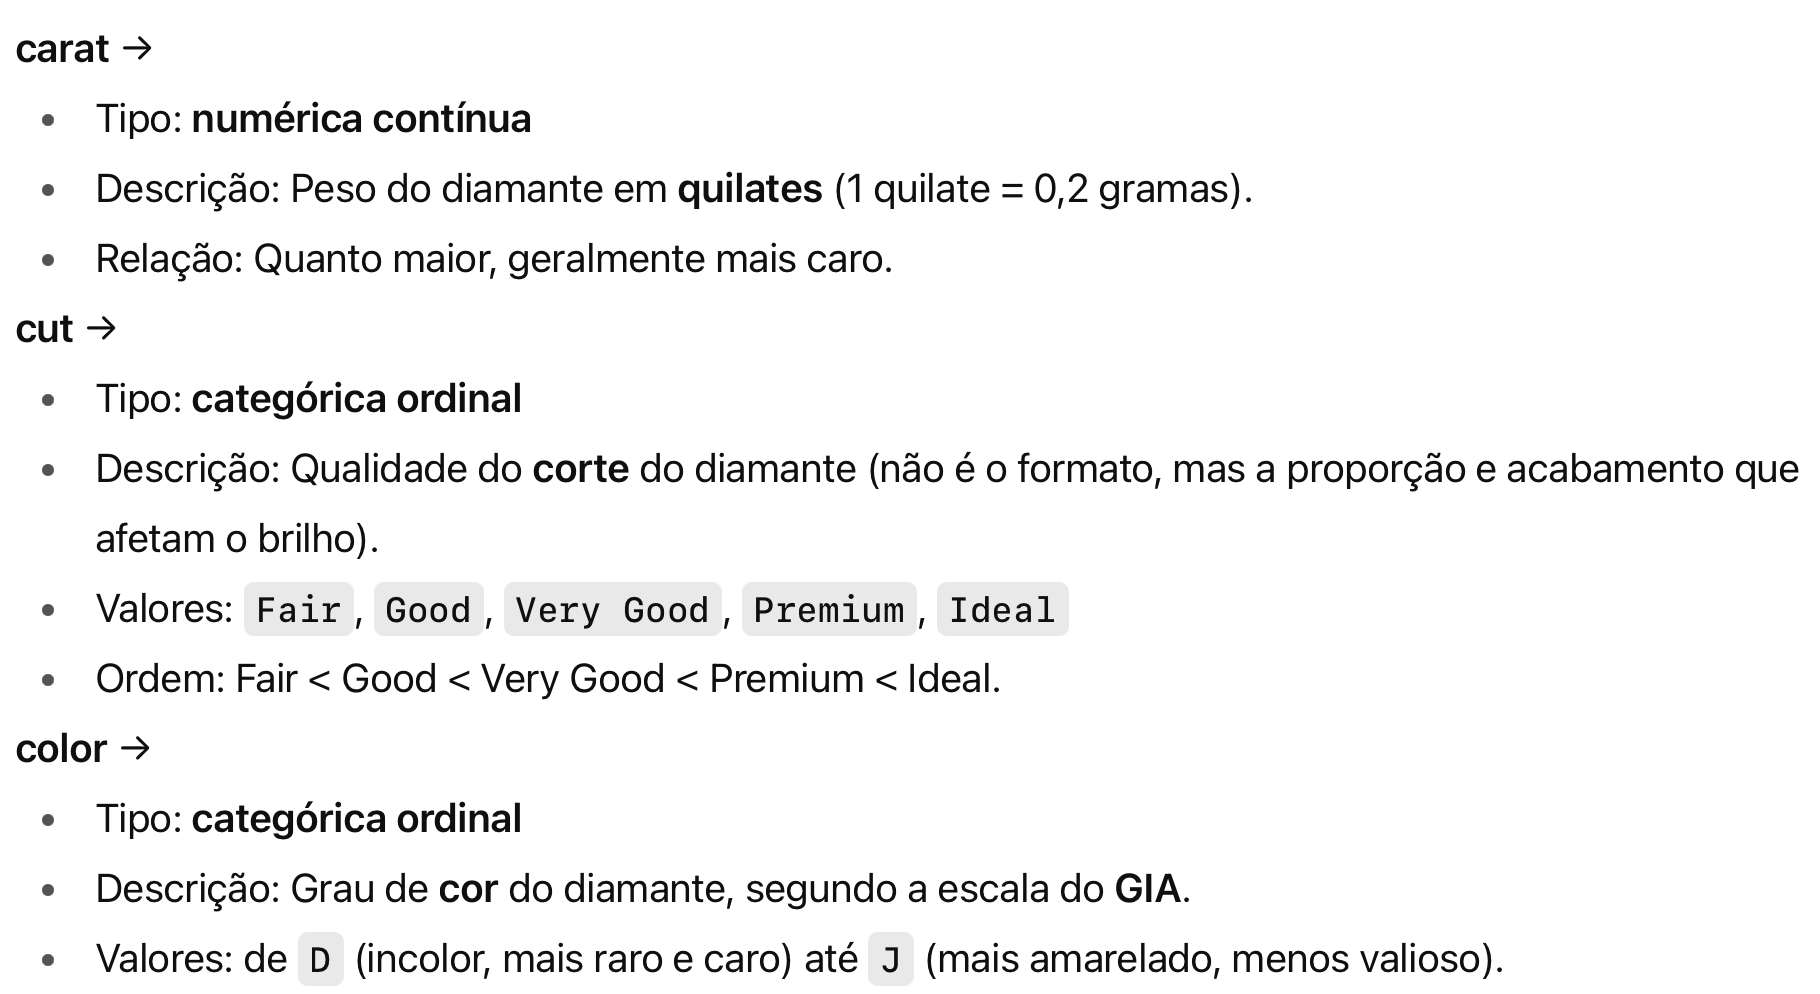

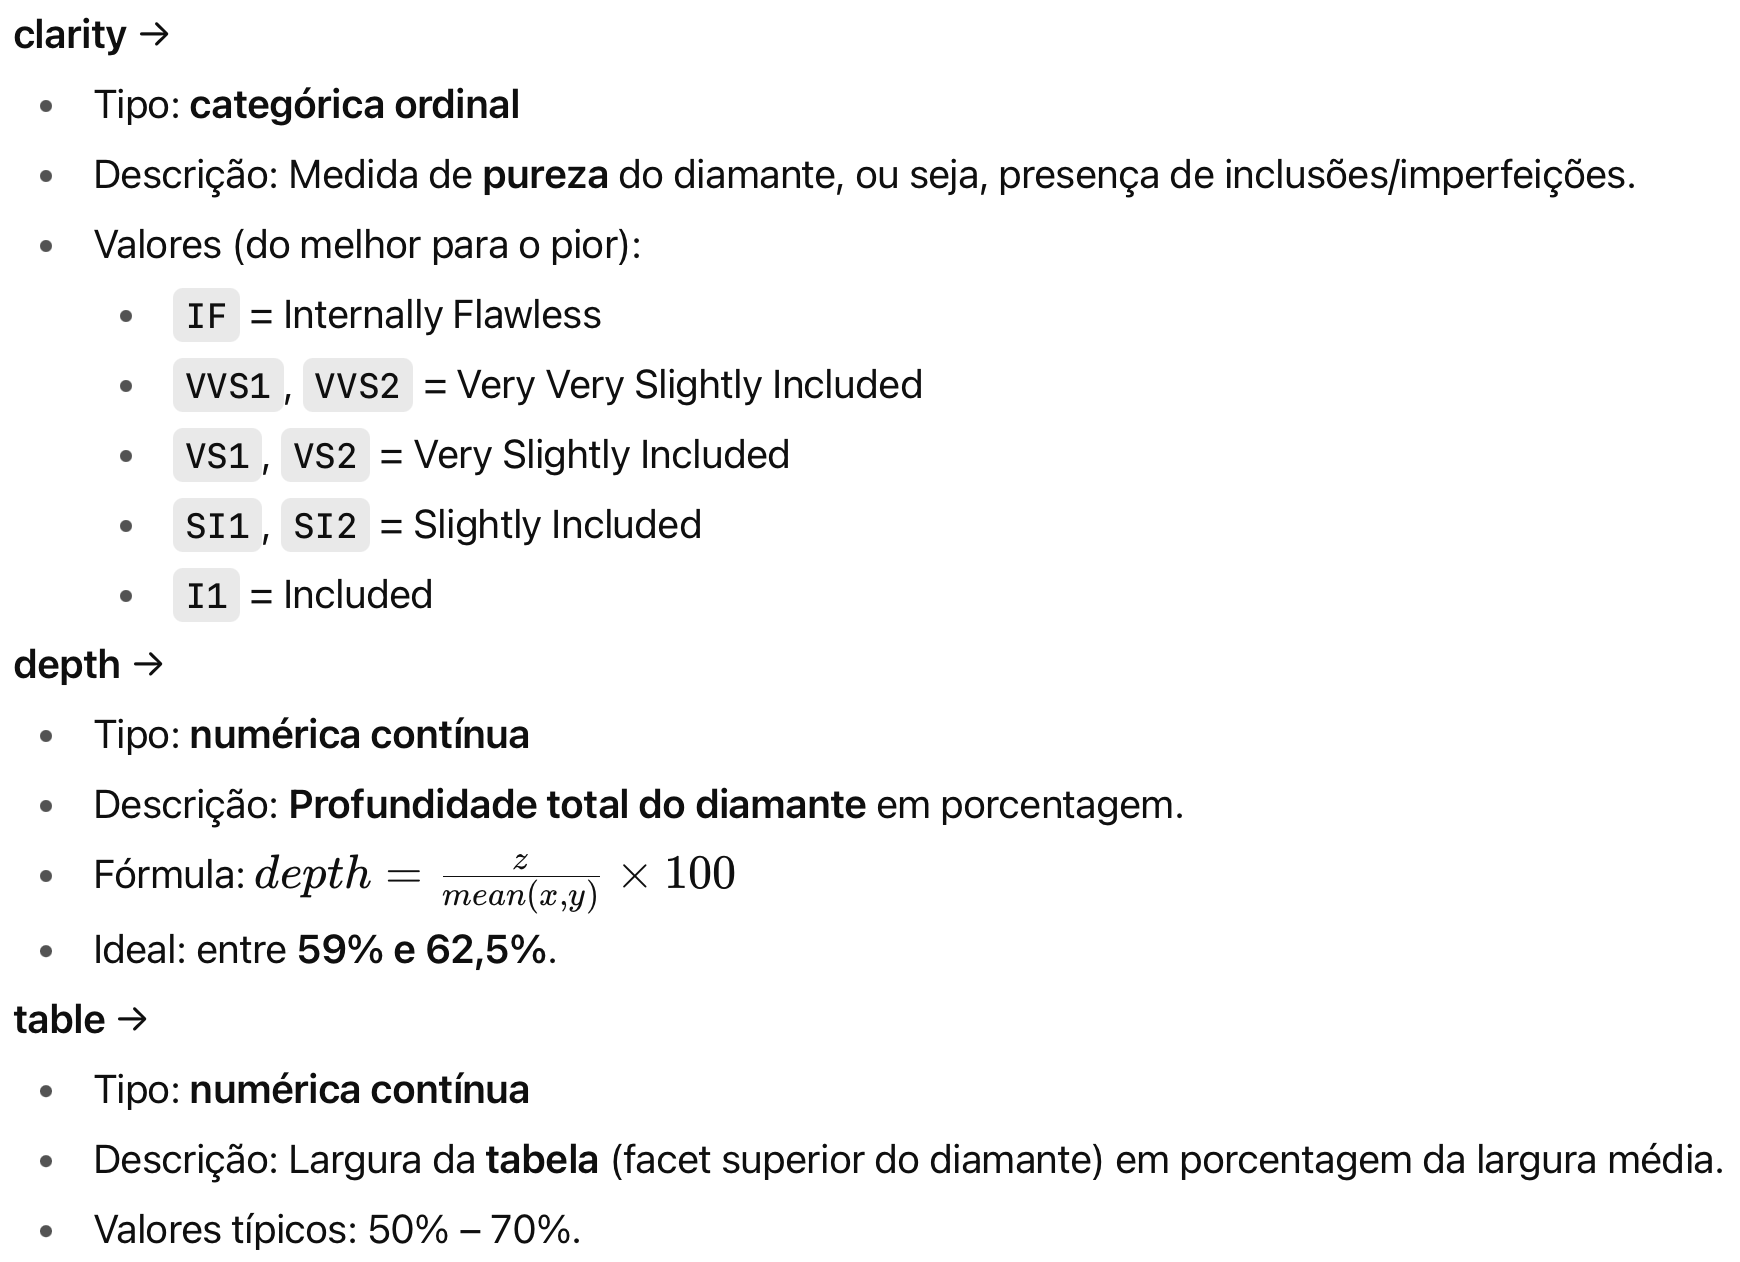

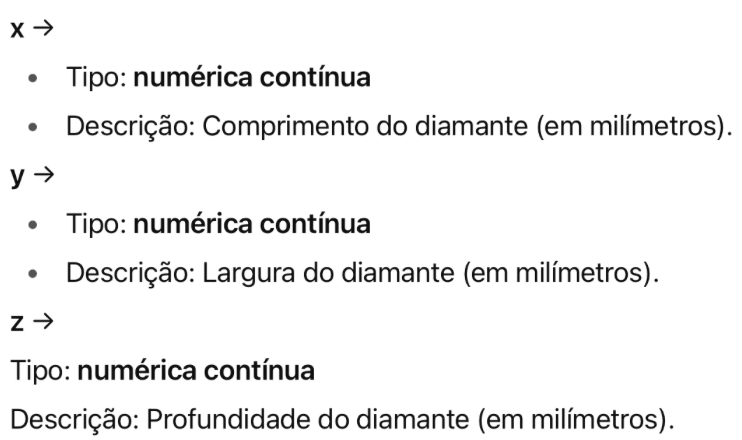

**COLUNA CUT: Avaliação:**
*   Low Quality: ["Fair", "Good", "Very Good"]
*   High Quality: ["Premium", "Ideal"]

# Workflow: Detalhamento das Atividades

##**Atividade A1**: Estatística Descritiva / Gráfica

###Atividade A1.1:

Análise da Estatística Descritiva / Gráfica de todas as variáveis Quantitativas (Discretas) do table

Segundo a descrição fornecida não há variáveis discretas neste dataset.

In [6]:
def statistic(_dataset):
  """
  DOCSTRING:
  Describe (without count) + Insert range: max - min
  """
  _describe = _dataset.describe()
  _describe = _describe.drop('count')
  _size = _describe.shape
  _describe.loc['range'] = _describe['max'] - _describe['min']
  _describe.loc['mode'] = stats.mode(_dataset, keepdims = False)[0]
  _describe = np.around(_describe.sort_values(), 2)
  return _describe

In [7]:
# função para gerar as estatísticas descritivas
def estatistica_descritiva(dataset, yLabel = None):

  _describe = statistic(dataset)

  # Símbolos da estatística estimada da população
  mean_mu = 'MÉDIA:  $\\overline{\mu}$ = '
  mean_mu += f'{_describe["mean"]: .2f}'

  median_mu = 'MEDIANA: $\\tilde{\mu}$ = '
  median_mu += f'{_describe["50%"]: .2f}'

  mode_mu = 'MODA: $\\hat{\mu}$ = '
  mode_mu += f'{_describe["mode"]: .2f}'

  enter = '\n'

  label = mean_mu + enter + median_mu + enter + mode_mu
  dataset.agg(statistic).plot(figsize = [15, 6], label='MEDIDAS DE RESUMO: ')
  plt.plot(list(_describe.index).index('mean'), _describe["mean"], 'D', label=mean_mu)
  plt.plot(list(_describe.index).index('50%'), _describe["50%"], 'D', label=median_mu)
  plt.plot(list(_describe.index).index('mode'), _describe["mode"], 'D', label=mode_mu)

  plt.title(f'ESTATÍSTICA DESCRITIVA')
  plt.legend()
  plt.ylabel(yLabel)
  plt.show()
  print(f'ESTATÍSTICA DESCRITIVA:')
  print(_describe)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Usuário\AppData\Local\Temp\ipykernel_9956\2818185621.py:7: SyntaxWarning: invalid escape sequence '\m'
  mean_mu = 'MÉDIA:  $\\overline{\mu}$ = '
C:\Users\Usuário\AppData\Local\Temp\ipykernel_9956\2818185621.py:10: SyntaxWarning: invalid escape sequence '\m'
  median_mu = 'MEDIANA: $\\tilde{\mu}$ = '
C:\Users\Usuário\AppData\Local\Temp\ipykernel_9956\2818185621.py:13: SyntaxWarning: invalid escape sequence '\m'
  mode_mu = 'MODA: $\\hat{\mu}$ = '


###Atividade A1.2:

Análise da Estatística Descritiva / Gráfica de todas as variáveis Quantitativas (Contínuas) do table

Estatísticas descritivas para a variável quantitativa contínua CARAT:


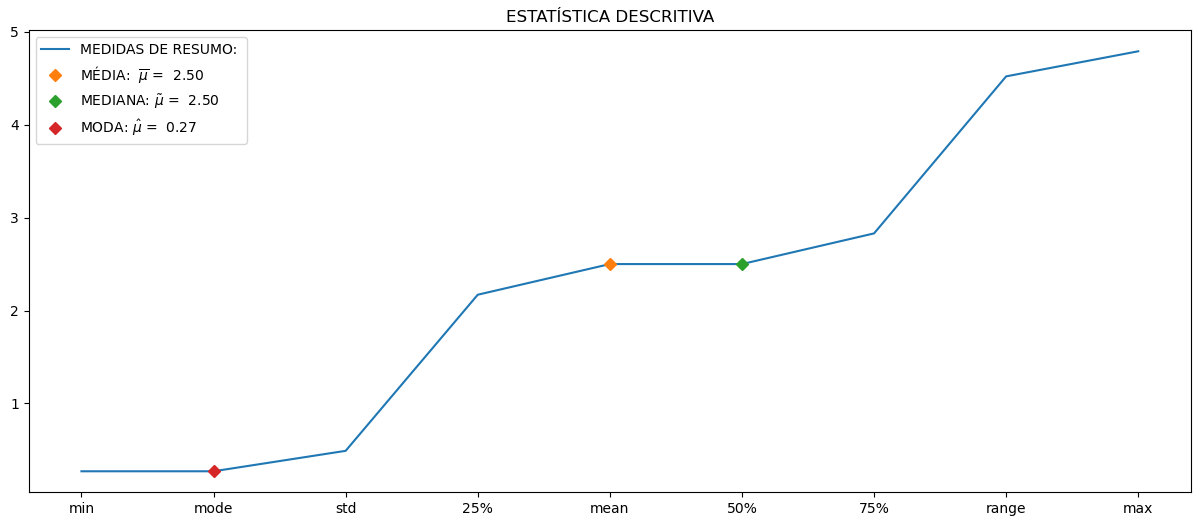

ESTATÍSTICA DESCRITIVA:
min      0.27
mode     0.27
std      0.49
25%      2.17
mean     2.50
50%      2.50
75%      2.83
range    4.52
max      4.79
Name: CARAT, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua DEPTH:


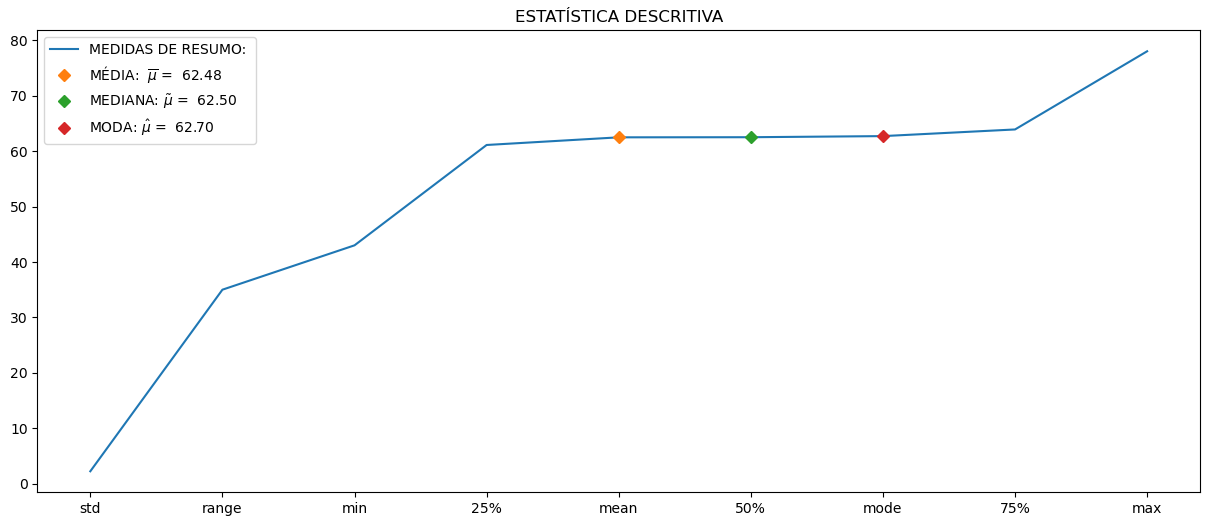

ESTATÍSTICA DESCRITIVA:
std       2.25
range    35.00
min      43.00
25%      61.10
mean     62.48
50%      62.50
mode     62.70
75%      63.90
max      78.00
Name: DEPTH, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua TABLE:


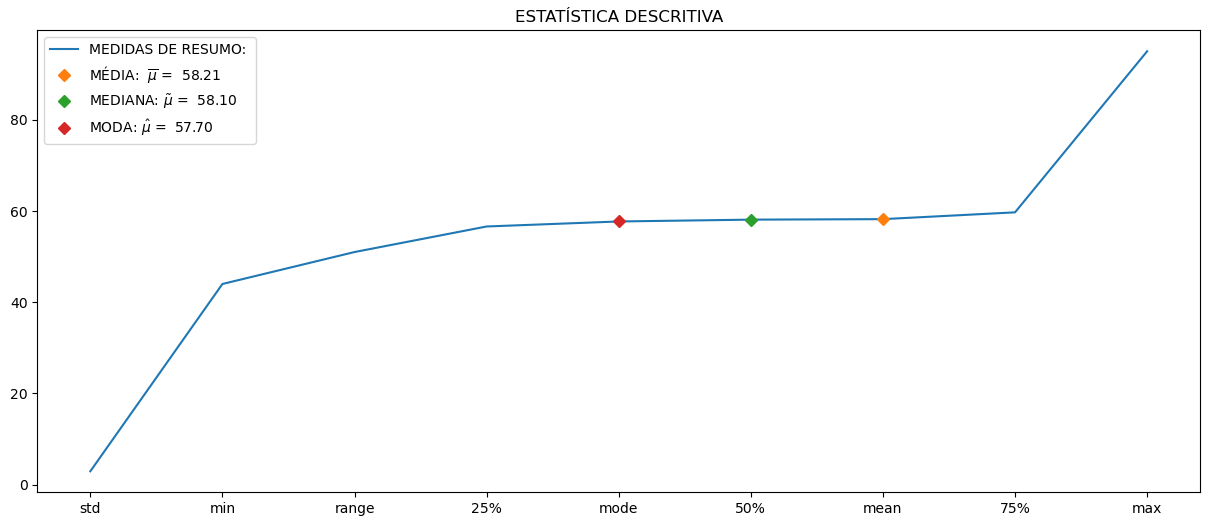

ESTATÍSTICA DESCRITIVA:
std       2.95
min      44.00
range    51.00
25%      56.60
mode     57.70
50%      58.10
mean     58.21
75%      59.70
max      95.00
Name: TABLE, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua X:


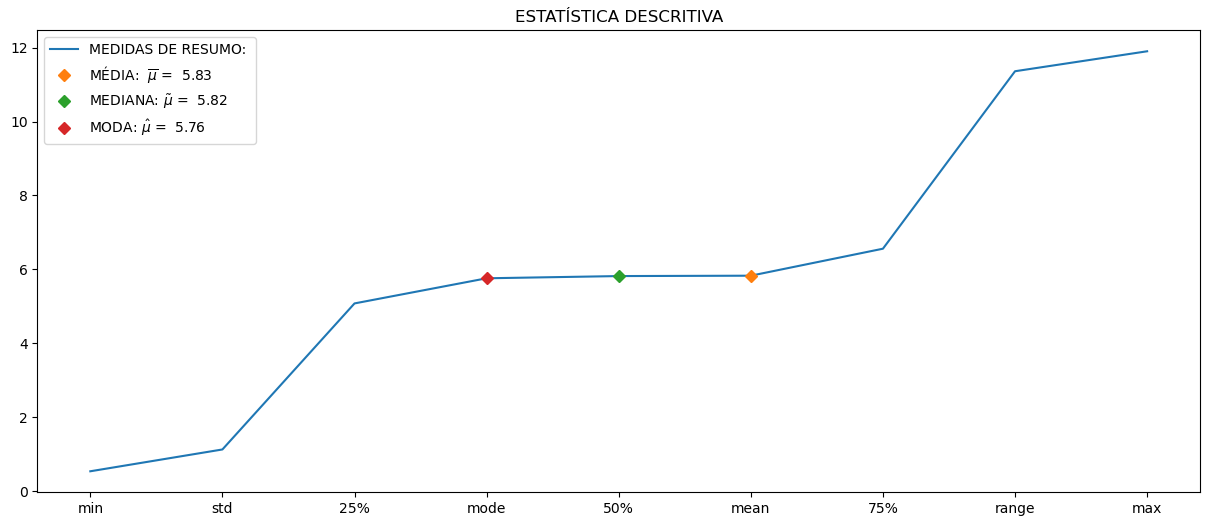

ESTATÍSTICA DESCRITIVA:
min       0.54
std       1.13
25%       5.08
mode      5.76
50%       5.82
mean      5.83
75%       6.56
range    11.36
max      11.90
Name: X, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua Y:


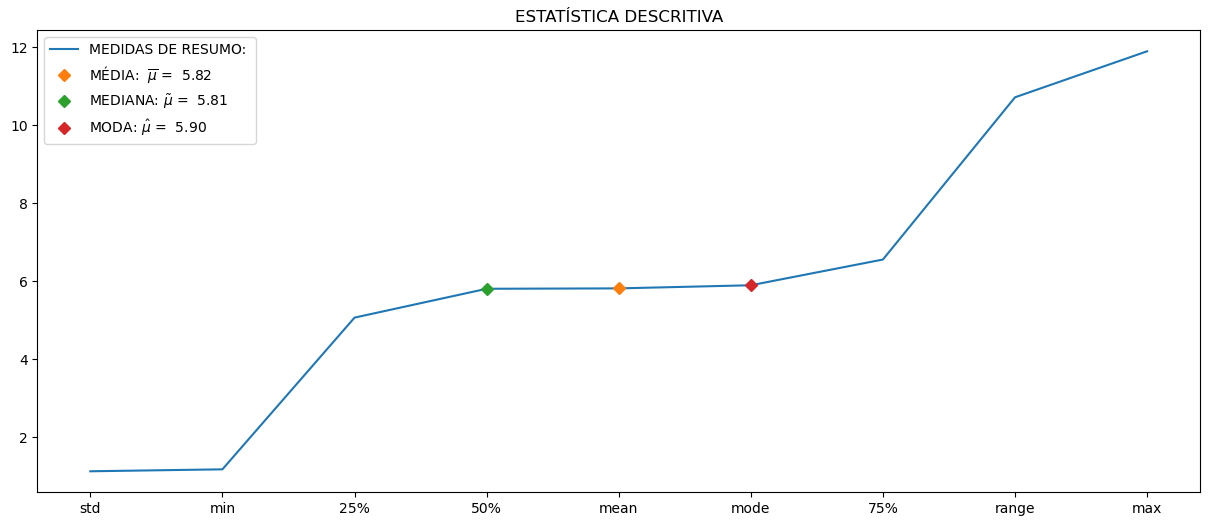

ESTATÍSTICA DESCRITIVA:
std       1.13
min       1.18
25%       5.07
50%       5.81
mean      5.82
mode      5.90
75%       6.56
range    10.72
max      11.90
Name: Y, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua Z:


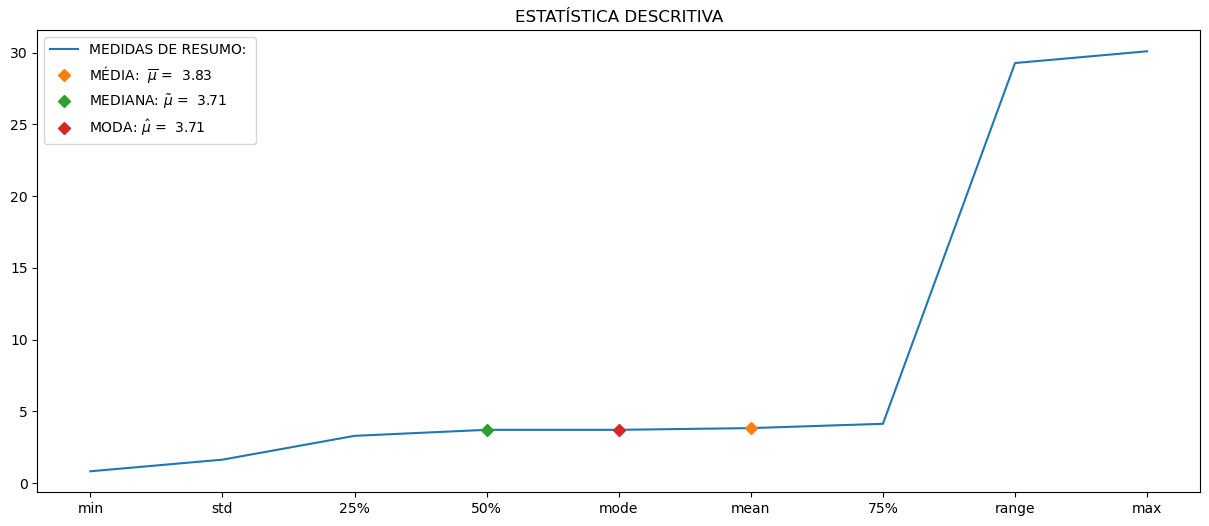

ESTATÍSTICA DESCRITIVA:
min       0.82
std       1.63
25%       3.29
50%       3.71
mode      3.71
mean      3.83
75%       4.13
range    29.28
max      30.10
Name: Z, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua XYZ:


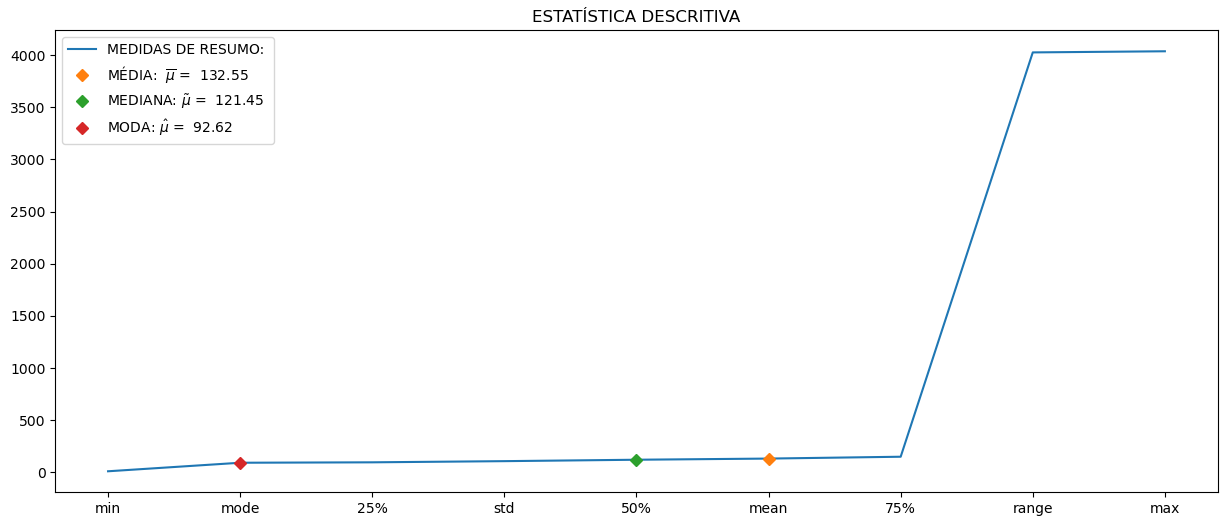

ESTATÍSTICA DESCRITIVA:
min        10.81
mode       92.62
25%        96.67
std       107.89
50%       121.45
mean      132.55
75%       150.24
range    4025.69
max      4036.50
Name: XYZ, dtype: float64
Estatísticas descritivas para a variável quantitativa contínua PRICE (US$):


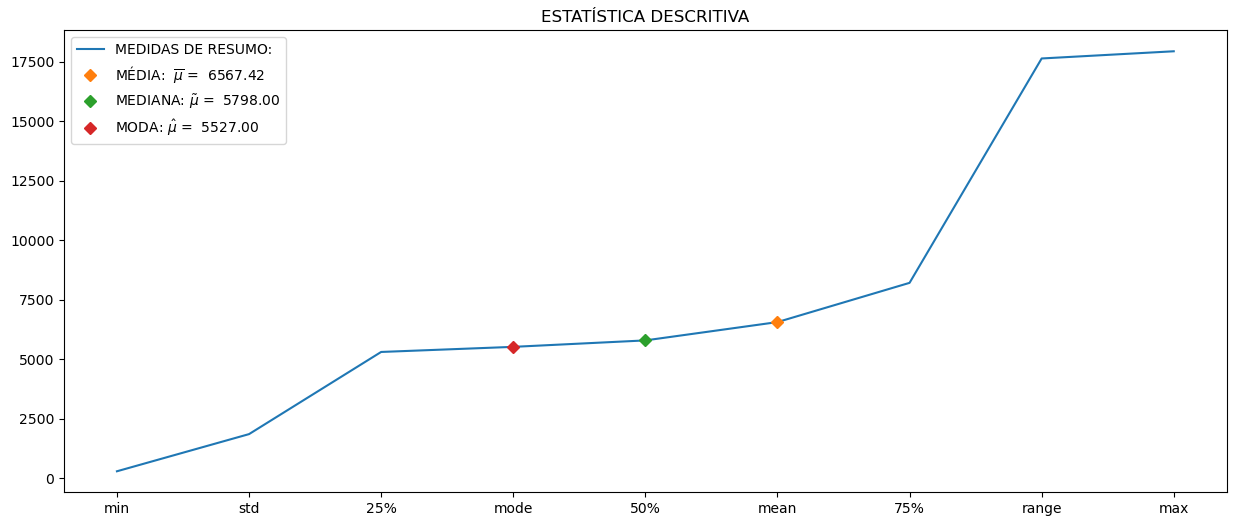

ESTATÍSTICA DESCRITIVA:
min        302.00
std       1862.83
25%       5313.00
mode      5527.00
50%       5798.00
mean      6567.42
75%       8215.00
range    17638.00
max      17940.00
Name: PRICE (US$), dtype: float64


In [8]:
# lista com as variáveis quantitativas contínuas
lista_var_quantitativas_continuas = ['CARAT', 'DEPTH', 'TABLE', 'X', 'Y', 'Z', 'XYZ', 'PRICE (US$)']

for col in lista_var_quantitativas_continuas:
    print(f'Estatísticas descritivas para a variável quantitativa contínua {col}:')
    estatistica_descritiva(table[col])

In [9]:
table.columns

Index(['CARAT', 'CUT', 'COLOR', 'CLARITY', 'DEPTH', 'TABLE', 'X', 'Y', 'Z',
       'XYZ', 'PRICE (US$)'],
      dtype='object')

In [10]:
# Definir total de bins para o histograma
total_amostras = table.shape[0]

BINS = int(np.ceil(1 + 3.32 * np.log(total_amostras)))
BINS

42

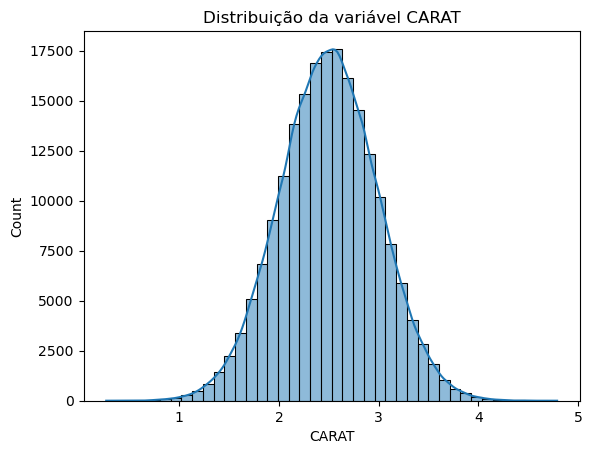

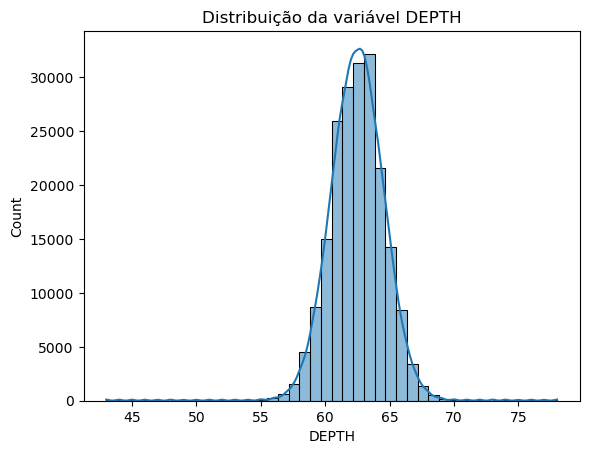

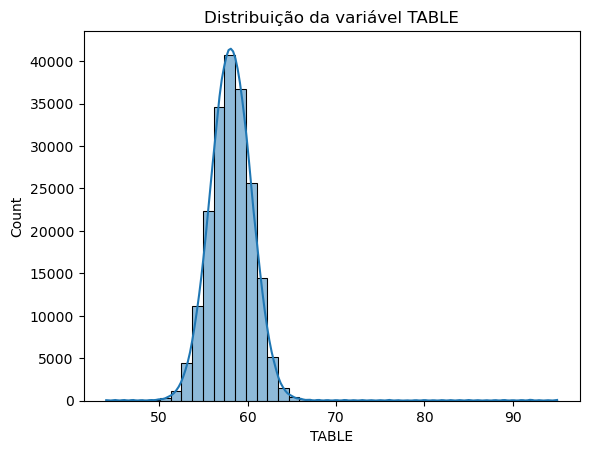

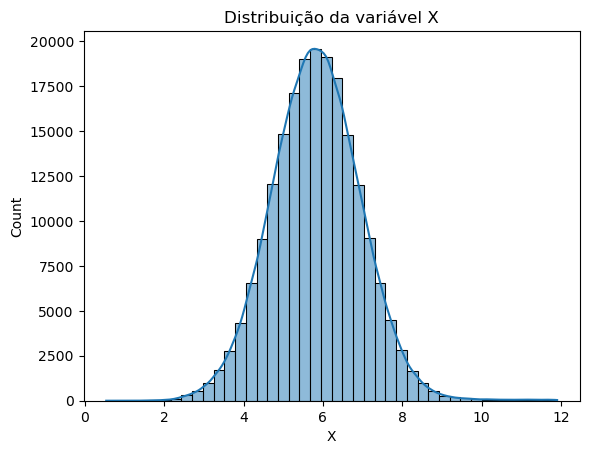

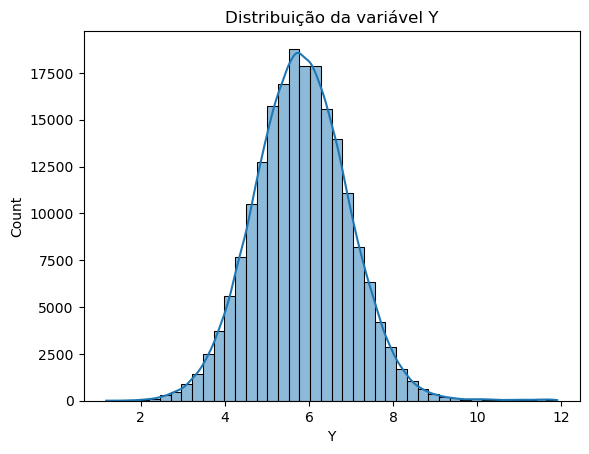

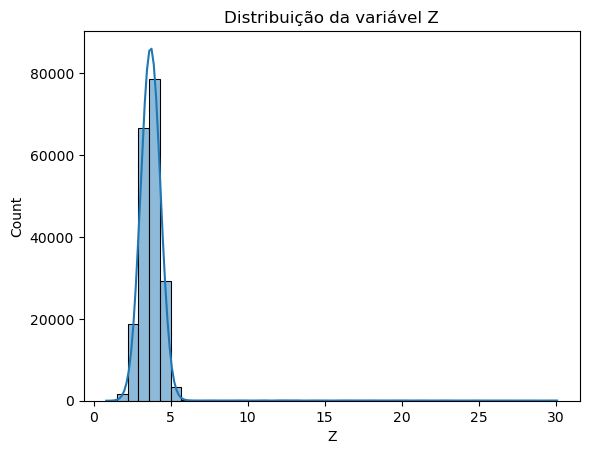

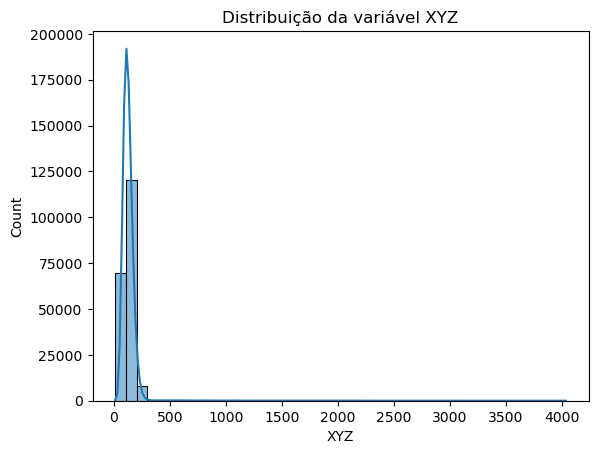

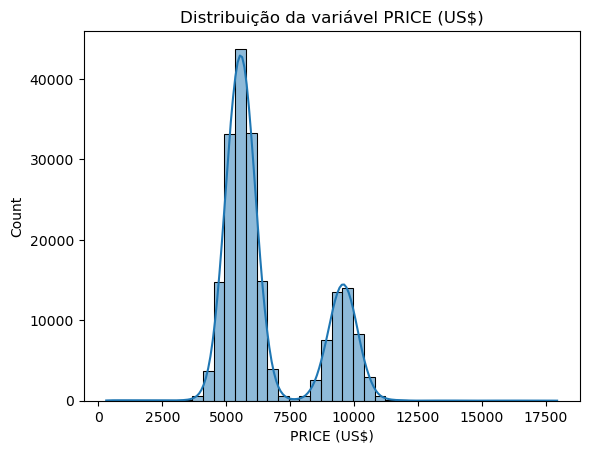

In [11]:
for col in lista_var_quantitativas_continuas:
    sns.histplot(data=table, x=col, kde=True, bins = BINS).set_title(f"Distribuição da variável {col}")
    plt.show()

In [12]:
# Coeficiente de variação para price
CV = table['PRICE (US$)'].std() / table['PRICE (US$)'].mean() * 100
print(f'Valor do Coeficiente de Variação da coluna: Price = {CV: .2f} %')

Valor do Coeficiente de Variação da coluna: Price =  28.36 %


In [13]:
# coeficiente de assimetria para price
CA = (3 * (table['PRICE (US$)'].mean() - table['PRICE (US$)'].median())) / table['PRICE (US$)'].std()
print(f'Valor do Coeficiente de Assimetria da coluna: price = {CA: .2f}')

Valor do Coeficiente de Assimetria da coluna: price =  1.24


###Atividade A1.3:

Análise da Estatística Descritiva / Gráfica de todas as variáveis Quanlitativas (Nominal) do table

In [14]:
def pareto(table, column = None):
  from matplotlib.ticker import PercentFormatter
  try:
    if(type(column) == str):
      cpycolumn = column
      se = table[column].value_counts()
      df = pd.DataFrame({se.index.name: list(se.values)},
                        list(se.index.values))
      df = df.rename(columns = {column: "FREQUÊNCIA ABSOLUTA"})
      df.index.name = column
      column = "FREQUÊNCIA ABSOLUTA"
      df = df.sort_values(by = column, ascending = False)
      df["FREQUÊNCIA RELATIVO (%)"] = round(df[column] / df[column].sum() * 100, 2)
      df["FREQUÊNCIA ACUMULADA (%)"] = round(df[column].cumsum() / df[column].sum() * 100, 2)
      fig, ax = plt.subplots()
      ax2 = ax.twinx()
      if (type(df.index.values[0]) == str): # dados qualitativos
        ax.bar(df.index.values, df[column].values, color="C0")
        ax2.plot(df.index.values, df["FREQUÊNCIA ACUMULADA (%)"].values, color="C1", marker="D", ms=7)
        ax2.yaxis.set_major_formatter(PercentFormatter())
        ax.tick_params(axis="y", colors="C0")
        ax2.tick_params(axis="y", colors="C1")
        plt.title(f'DIAGRAMA DE PARETO\nVARIÁVEL QUALITATIVA: {cpycolumn}')
        plt.show()
        print(df)
      elif (type(df.index.values[0]) != float): #dados discretos
        array = [str(valor) for valor in (df.index.values)] # int to str
        ax.bar(array, df[column].values, color="C0")
        ax2.plot(array, df["FREQUÊNCIA ACUMULADA (%)"].values, color="C1", marker="D", ms=7)
        ax2.yaxis.set_major_formatter(PercentFormatter())
        ax.tick_params(axis="y", colors="C0")
        ax2.tick_params(axis="y", colors="C1")
        plt.title(f'DIAGRAMA DE PARETO\nVARIÁVEL QUANTITATIVA DISCRETA: {cpycolumn}')
        plt.show()
        print(f'{df}', end = ' ')
      else:
        print(table)
    else:
      print(table)
  except:
    print(f'ERRO: {table}')

In [15]:
lista_var_qualitativas_nominais = ['CUT', 'COLOR', 'CLARITY']

Tabela de frequência e diagrama de Pareto para a variável CUT



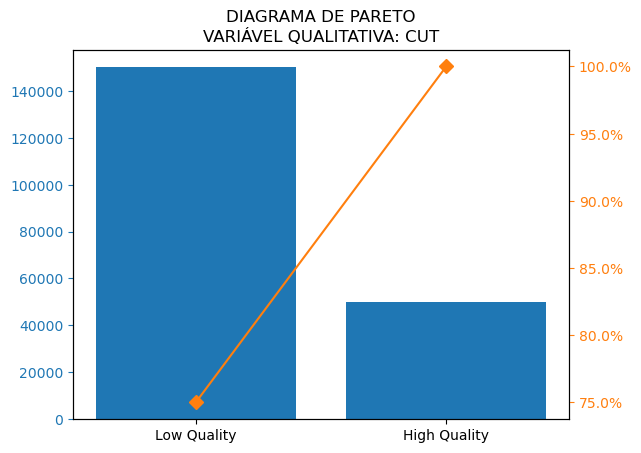

              FREQUÊNCIA ABSOLUTA  FREQUÊNCIA RELATIVO (%)  \
CUT                                                          
Low Quality                150000                     75.0   
High Quality                50000                     25.0   

              FREQUÊNCIA ACUMULADA (%)  
CUT                                     
Low Quality                       75.0  
High Quality                     100.0  
None

Tabela de frequência e diagrama de Pareto para a variável COLOR



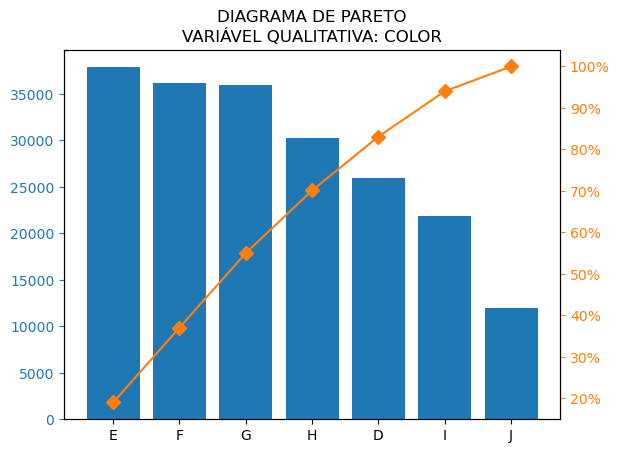

       FREQUÊNCIA ABSOLUTA  FREQUÊNCIA RELATIVO (%)  FREQUÊNCIA ACUMULADA (%)
COLOR                                                                        
E                    37857                    18.93                     18.93
F                    36165                    18.08                     37.01
G                    35922                    17.96                     54.97
H                    30262                    15.13                     70.10
D                    25955                    12.98                     83.08
I                    21884                    10.94                     94.02
J                    11955                     5.98                    100.00
None

Tabela de frequência e diagrama de Pareto para a variável CLARITY



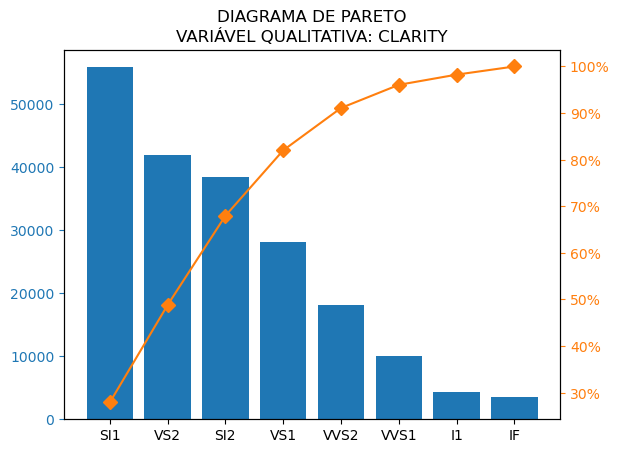

         FREQUÊNCIA ABSOLUTA  FREQUÊNCIA RELATIVO (%)  \
CLARITY                                                 
SI1                    55755                    27.88   
VS2                    41831                    20.92   
SI2                    38313                    19.16   
VS1                    28109                    14.05   
VVS2                   18163                     9.08   
VVS1                    9957                     4.98   
I1                      4375                     2.19   
IF                      3497                     1.75   

         FREQUÊNCIA ACUMULADA (%)  
CLARITY                            
SI1                         27.88  
VS2                         48.79  
SI2                         67.95  
VS1                         82.00  
VVS2                        91.09  
VVS1                        96.06  
I1                          98.25  
IF                         100.00  
None



In [16]:
for col in lista_var_qualitativas_nominais:
    print(f'Tabela de frequência e diagrama de Pareto para a variável {col}\n')
    print(f'{pareto(table, col)}\n')

###Atividade A1.4:

Análise da Estatística Descritiva / Gráfica de todas as variáveis Quanlitativas (Ordinal) do table

Segundo a descrição fornecida não há variáveis ordinais neste dataset.

### Agrupamentos

In [17]:
# CUT
price_cut = table.groupby('CUT')['PRICE (US$)'].agg(['mean', 'median', 'std'])
price_cut

,mean,median,std
CUT,,,
High Quality,9584.183380,9568.0,689.226245
Low Quality,5561.833893,5556.0,650.902349


In [18]:
price_color = table.groupby('COLOR')['PRICE (US$)'].agg(['mean', 'median', 'std'])
price_color

,mean,median,std
COLOR,,,
D,6584.383741,5800.0,1871.048085
E,6548.584727,5782.0,1862.372319
F,6568.356173,5799.0,1862.623737
G,6581.903792,5807.0,1866.632089
H,6552.613872,5793.0,1853.880069
I,6572.529702,5805.0,1864.738387
J,6572.029360,5811.0,1854.371882


In [19]:
price_clarity= table.groupby('CLARITY')['PRICE (US$)'].agg(['mean', 'median', 'std'])
price_clarity

,mean,median,std
CLARITY,,,
I1,6562.190400,5793.0,1862.848942
IF,6551.218473,5789.0,1857.819136
SI1,6571.366622,5803.0,1858.208415
SI2,6573.017722,5798.0,1865.608549
VS1,6570.461240,5803.0,1861.387891
VS2,6561.401879,5788.0,1869.800998
VVS1,6550.172441,5789.0,1855.282368
VVS2,6566.498981,5805.0,1862.636230


### RELATÓRIO PARCIAL

Fazer aqui o **RELATÓRIO** com todas as conclusões e resultados que serão apresentados as gestores da **EMPRESA:**.

A análise descritiva para a variável PRICE evidencia que a média é superior à mediana, indicando que a distribuição é assimétrica positiva, ou seja, há uma cauda longa à direita. O coeficiente de assimetria de 1.24 evidencia que essa assimetria é forte.

O histograma para a variável Price evidencia a presença de dois picos na distribuição, ou seja, há uma distribuição bimodal.

Isso indica a presença de dois grupos distintos de diamantes:
* Primeiro pico: entre 5000 e 6000, e é o grupo com maior frequência.
* Segundo pico: entre 9000 e 10000, é o grupo com menor frequência.

A variabilidade dos dados sugere a presença de valores extremos/outliers, que reforça a distribuição assimétrica observada no histograma, ou seja, há diamantes com preços muito superiores à média. O valor de CV está entre 20% e 35%, reforçado que há uma razoável variabilidade em torno da média.

A análise de frequências para a variável CUT evidencia que o subgrupo com Low Quality possui maior frequência e representa 75% do dataset, enquanto o subgrupo High Quality representa 25%. Logo, essa desproporção faz com que a  média geral seja influenciada pelo preço dos diamantes com Low Quality.
Além disso, nota-se que para cada grupo de CUT, a média e a mediana são próximas, o que reforça que há simetria entre os dados de cada categoria. 

Todavia, a diferença entre as médias dos preços dos dois grupos de CUT, indica que a qualidade do corte é uma variável relevante para definição do preço de um diamante.

#### RESUMINDO OS RESULTADOS DOS DIAMANTES - CUT: Grupo Low Quality

*   ✅ . Representa 75% do dataset com 150000 dados.
*   ✅ . A média de preço para esse grupo é de 5562.
*   ✅ . A mediana é 5556, ou seja, próxima a média. O desvio padrão é de 650.9

#### RESUMINDO OS RESULTADOS DOS DIAMANTES - CUT: Grupo High Quality

*   ✅ . Representa 25% do dataset com 50000 dados.
*   ✅ . A média de preço para esse grupo é de 9584.
*   ✅ . A mediana é 9568, ou seja, próxima a média. O desvio padrão é de 689.23

##**Atividade A2**: Análise de Outliers

In [20]:
#Método do Quartil.

for col in table.drop(columns= ['CUT', 'COLOR', 'CLARITY']):
    
    Q1 = table[col].quantile(0.25)
    Q3 = table[col].quantile(0.75)
    IQR = Q3 - Q1
    
    aux_outliers = table[(table[col] < Q1-(IQR*1.5)) 
                   | (table[col] > Q3+(IQR*1.5))]
    
    indices_outliers = aux_outliers.index.tolist()
    
    if len(indices_outliers) >= 1:
        
        print(f"A coluna {col} tem {len(indices_outliers)} outliers!")

    else:
        
        print(f"Acoluna {col} não tem outliers!")
        
    print()
    print("="*80)
    print()

A coluna CARAT tem 1447 outliers!


A coluna DEPTH tem 2314 outliers!


A coluna TABLE tem 2905 outliers!


A coluna X tem 2089 outliers!


A coluna Y tem 2024 outliers!


A coluna Z tem 3185 outliers!


A coluna XYZ tem 4221 outliers!


A coluna PRICE (US$) tem 310 outliers!




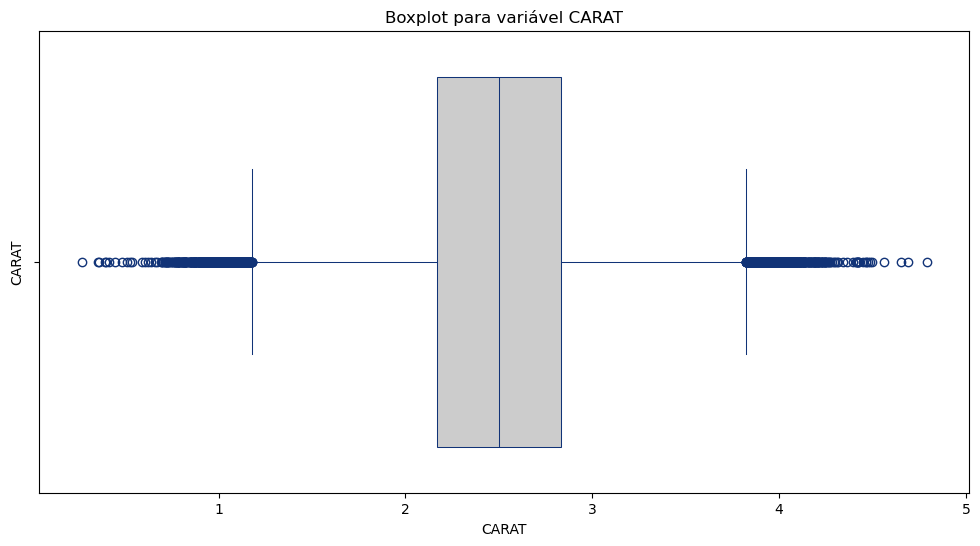

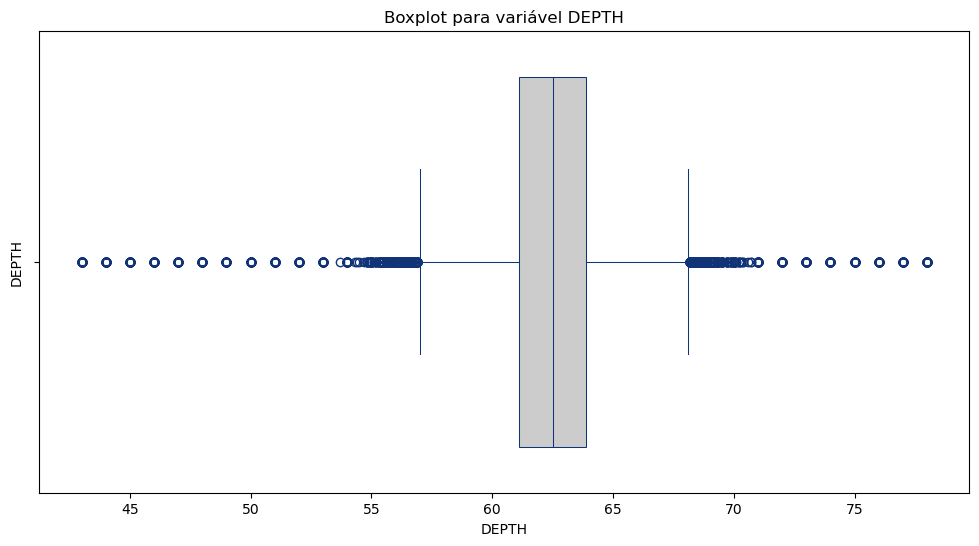

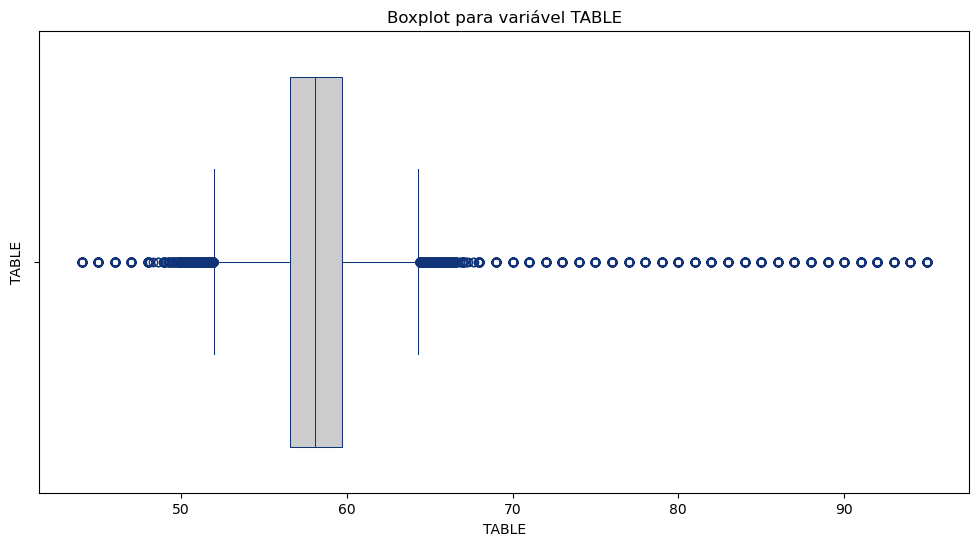

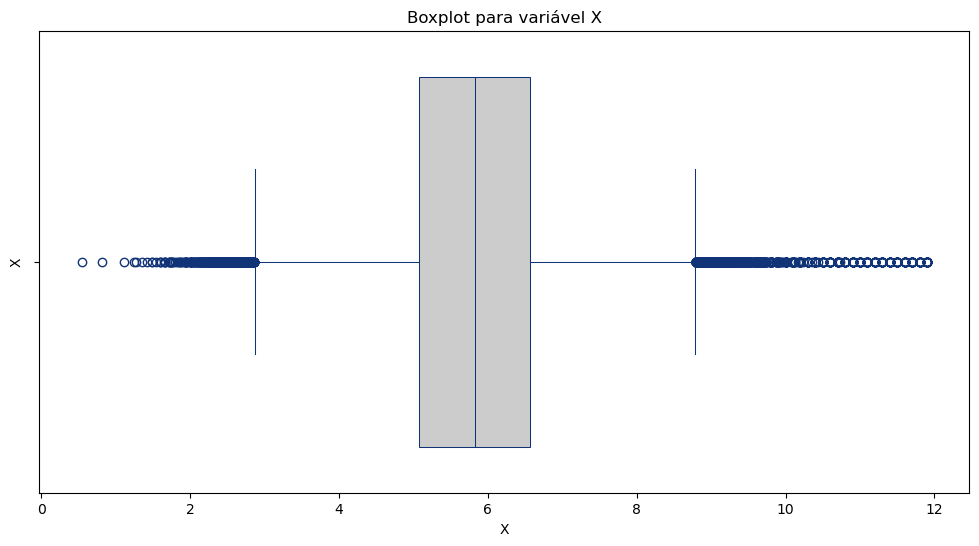

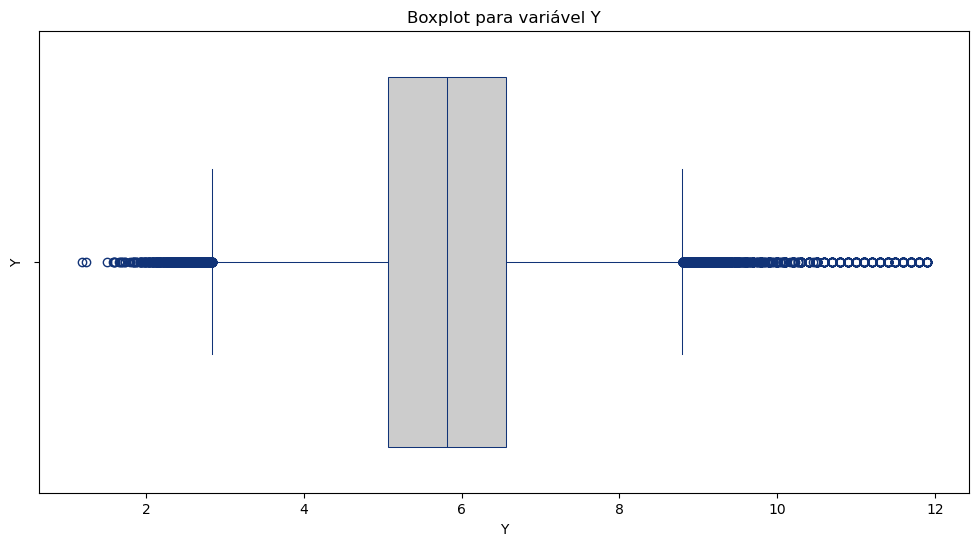

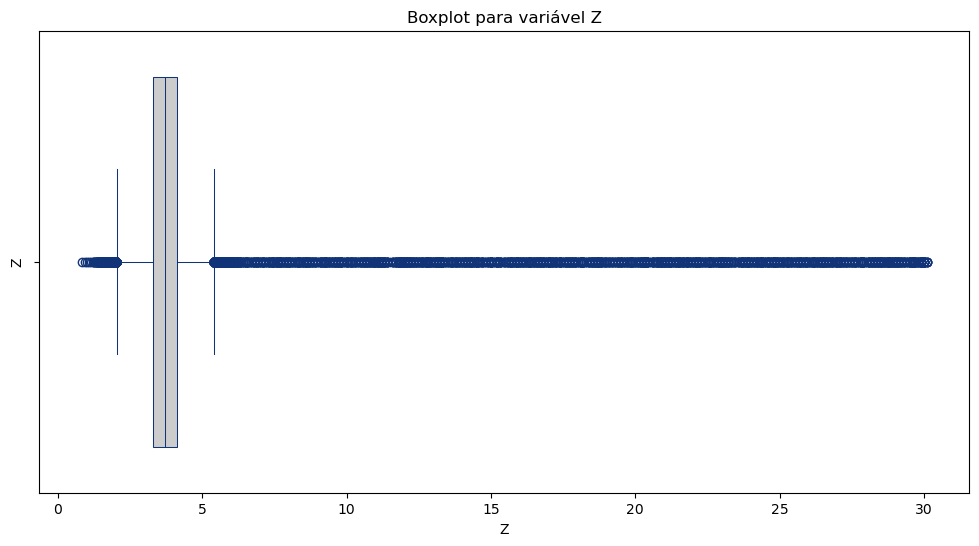

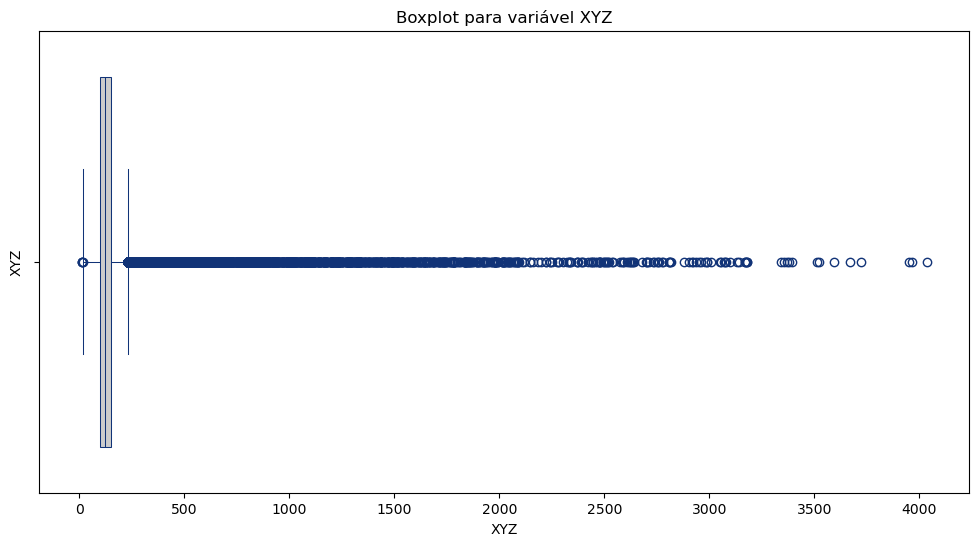

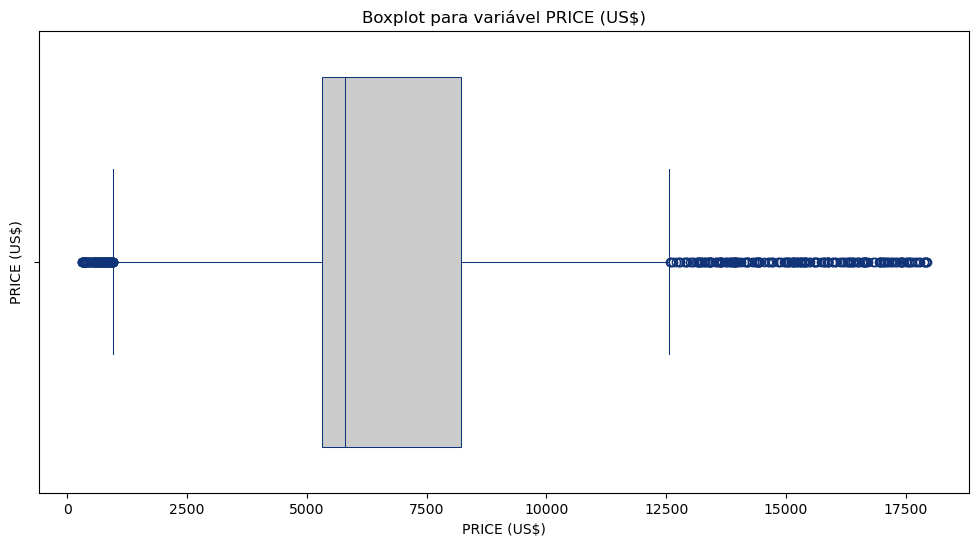

In [21]:
# Boxplot
for col in table.drop(columns= ['CUT', 'COLOR', 'CLARITY']):
    plt.figure(figsize = (12,6))
    sns.boxplot(x=table[col], color=".8", linecolor="#137", linewidth=.75)
    plt.title(f'Boxplot para variável {col}')
    plt.ylabel(col)
    plt.show()
    

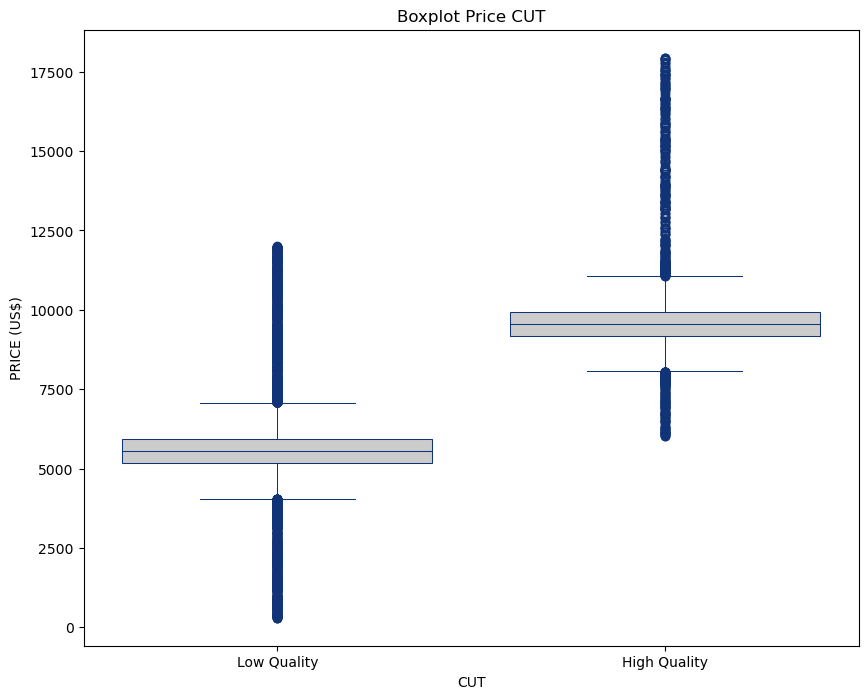

In [22]:
# Boxplot Price por CUT
plt.figure(figsize=(10,8))
sns.boxplot(data=table, x="CUT", y="PRICE (US$)", color=".8", linecolor="#137", linewidth=.75)
plt.title('Boxplot Price CUT')
plt.show()

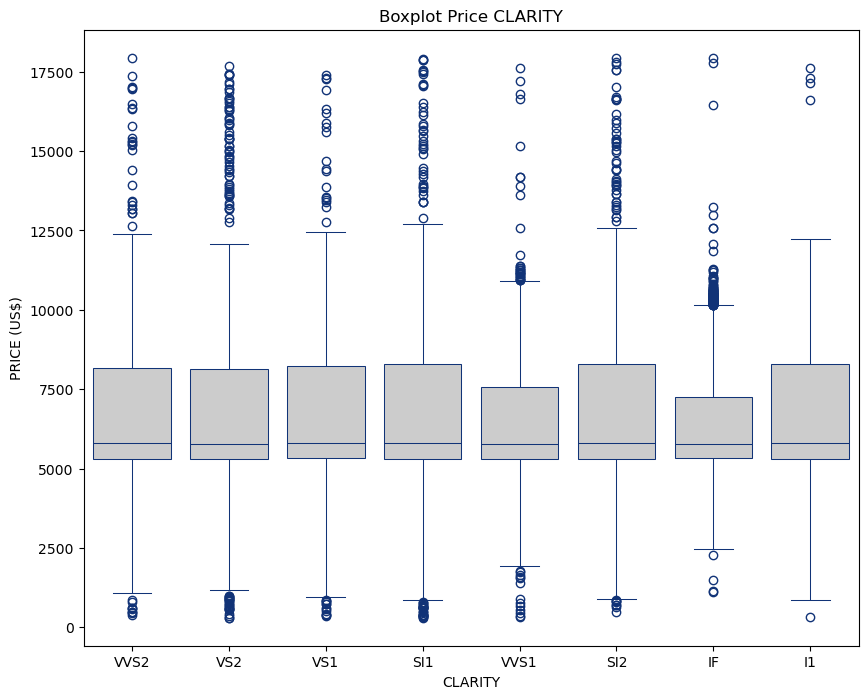

In [23]:
# Boxplot Price por CLARITY
plt.figure(figsize=(10,8))
sns.boxplot(data=table, x="CLARITY", y="PRICE (US$)", color=".8", linecolor="#137", linewidth=.75)
plt.title('Boxplot Price CLARITY')
plt.show()

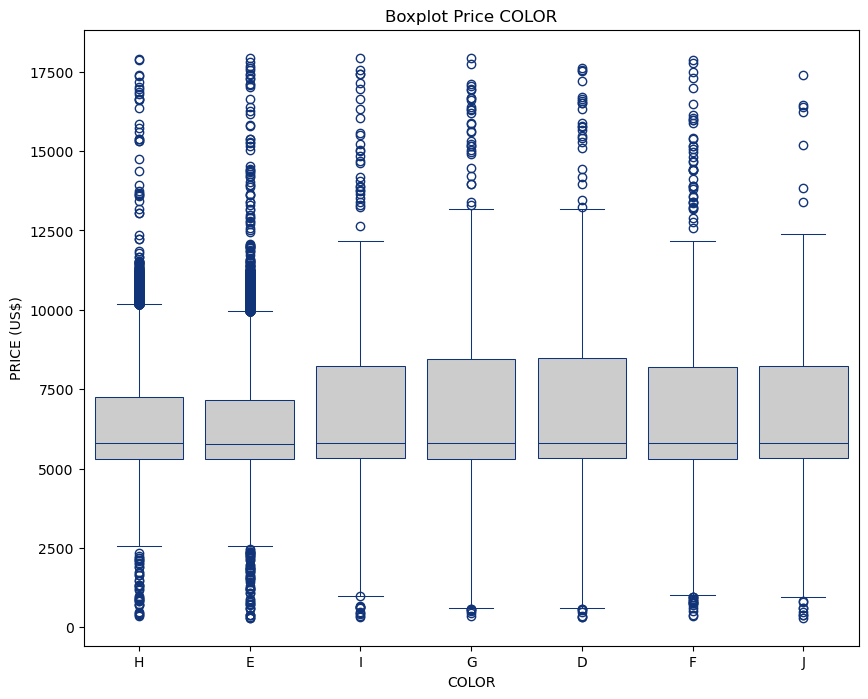

In [24]:
# Boxplot Price por COLOR
plt.figure(figsize=(10,8))
sns.boxplot(data=table, x="COLOR", y="PRICE (US$)", color=".8", linecolor="#137", linewidth=.75)
plt.title('Boxplot Price COLOR')
plt.savefig('boxplot price color.png')
plt.show()

In [25]:
df_sem_outliers = table[(table['PRICE (US$)'] > Q1-(IQR*1.5)) & (table['PRICE (US$)'] < Q3+(IQR*1.5))]
df_sem_outliers.shape

(199690, 11)

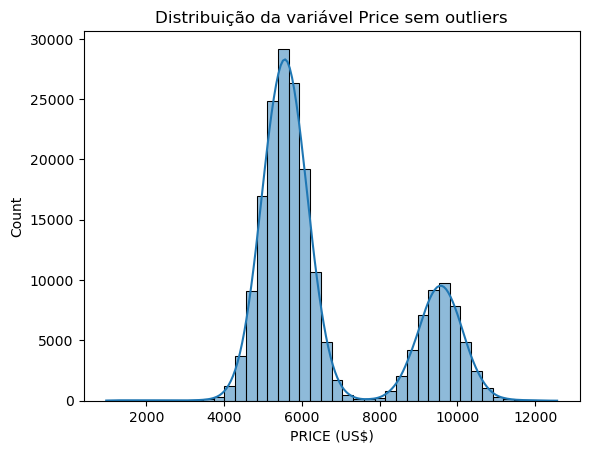

In [26]:
sns.histplot(data=df_sem_outliers, x='PRICE (US$)', kde=True, bins = BINS).set_title(f"Distribuição da variável Price sem outliers")
plt.show()

### RELATÓRIO PARCIAL

Há presença de outliers no dataset em todas as colunas. Na variável target, Price, há a presença de 310 outliers,  os quais foram removidos da amostra visto que esses valores discrepantes afetam a média e o desvio padrão da amostra, o que pode resultar em resultados estatisticamente errados. Além disso, a maioria dos algoritmos de machine learning não apresentam bom funcionamento quando há outliers na amostra, sendo desejável removê-los.

A análise do gráfico de boxplot confirma a presença de valores altos para a variável Price, há presença de vários valores acima de aproximadamente 10000, que provavelmente consistem em diamantes com melhores características. Além disso, os preços se encontram marjoritariamente entre 5000 e 8000, com maior frequência de preços acima da mediana.

O boxplot para variável price considerando CUT reforça o que já foi obtido na análise descritiva, a diferença entre as medianas dos dois grupos indica que a variável CUT tem forte influência no preço final do diamante. Além disso, é possível observar que as caixas de ambos os tipos de corte são estreitas, indicando baixa variabilidade dos preços dentro de cada categoria. Ou seja, isso evidencia que os diamantes presentes em cada categoria tendem a ter preços semelhantes, havendo pouca disperção entre si, apesar dos outliers.


### RESUMINDO OS RESULTADOS DOS DIAMANTES - CUT: Grupo Low Quality

*   ✅ .  Preços entre 4000 e 7000 doláres, e mediana em torno de 5500.
*   ✅ . Presença de outliers em ambas as extremidades do boxplot.

### RESUMINDO OS RESULTADOS DOS DIAMANTES - CUT: Grupo High Quality

*   ✅ . Preços entre 8000 e 11000 dólares, e mediana próxima de US$ 9500.
*   ✅ . Presença de outliers em ambas as extremidades do boxplot.
*   ✅ .

##**Atividade A3**: Análise de Reamostragem: Downsampling ? ou Upsampling ?

In [27]:
# Usando o método bootstrap com reposição
N_Boot = 5000 # total de reamostragens
alpha = 0.05

def bootstrap(col, N_Boot, alpha, statfun):
    x = np.array(col)
    resample_stat = []
    for k in range(N_Boot):
        index = np.random.randint(0, len(x), len(x))
        sample = x[index]
        bstatistic = statfun(sample)
        resample_stat.append(bstatistic)

    lower_bound = np.percentile(resample_stat, 100 * (alpha / 2))
    upper_bound = np.percentile(resample_stat, 100 * (1 - alpha / 2))

    results = {
        'Resample Stat': np.array(resample_stat),
        'Original Mean': np.mean(col),
        'Bootstrpa Mean': np.mean(resample_stat),
        'Lower CI': lower_bound,
        'Upper CI': upper_bound,
        'IC Range': upper_bound - lower_bound
    }

    return results


In [31]:
price_bootstrap = bootstrap(df_sem_outliers['PRICE (US$)'], N_Boot, alpha,  np.mean)

for key, value in price_bootstrap.items():
    print(f'{key}: {value}')

Resample Stat: [6558.93555511 6559.11375632 6555.22702188 ... 6565.66504582 6566.23369723
 6562.16893685]
Original Mean: 6560.935980770194
Bootstrpa Mean: 6560.969705841054
Lower CI: 6552.861775877611
Upper CI: 6569.156481921979
IC Range: 16.294706044368468


In [32]:
margem_erro = price_bootstrap['IC Range']/2
print(f'A margem de erro é {margem_erro: .2f}')

A margem de erro é  8.15


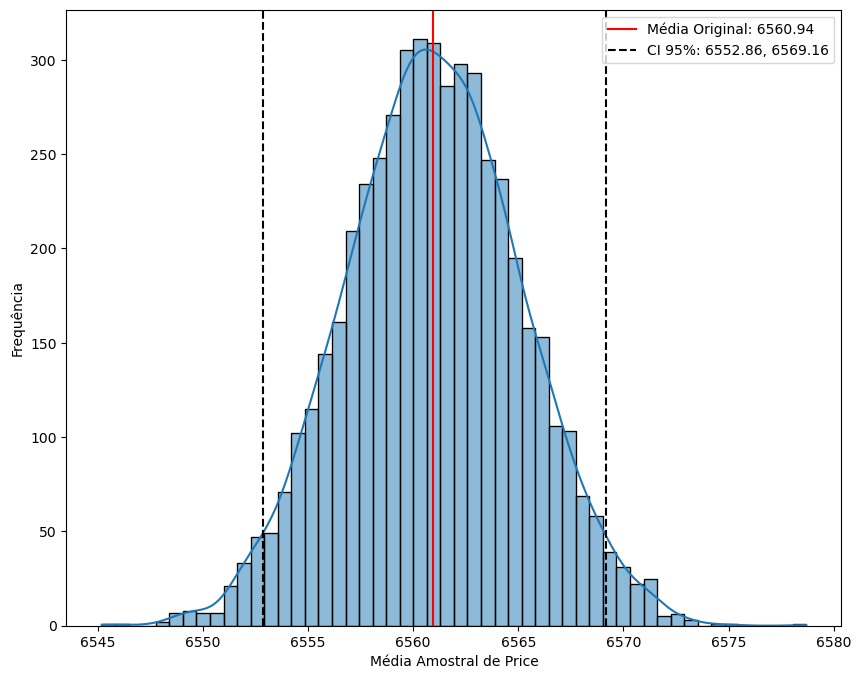

In [33]:
plt.figure(figsize = (10,8))
ax = sns.histplot(price_bootstrap['Resample Stat'], kde=True, bins='auto')

ax.axvline(price_bootstrap['Original Mean'], color="red", linestyle="-", label=f'Média Original: {price_bootstrap['Original Mean']:.2f}')
ax.axvline(price_bootstrap['Lower CI'], color="black", linestyle="--", label=f'CI 95%: {price_bootstrap['Lower CI']:.2f}, {price_bootstrap['Upper CI']:.2f}')
ax.axvline(price_bootstrap['Upper CI'], color="black", linestyle="--")
plt.ylabel('Frequência')
plt.xlabel('Média Amostral de Price')
plt.legend()
plt.show()

### RELATÓRIO PARCIAL


A diferença entre a média original e a média obtida com o método bootstrap é próxima de 0, isso indica que a média amostral é uma boa estimativa da média populacional. A amplitude dos intervalos é de apenas 16,3, o que gera uma margem de erro de apenas 8.15 indicando que a estimativa de média é precisa. Sendo assim, não há necessidade aplicar técnicas de downsampling ou undersampling.


### RESUMINDO OS RESULTADOS DOS DIAMANTES:

*   ✅ . O método bootstrap demonstra que com n = 5.000 reamostragens, obtém-se uma margem de erro de ±8.
*   ✅ . Não há necessidade de downsampling ou undersampling da amostra.

# RELATÓRIO GERAL: CONCLUSÕES GERAIS:

## RESPONDER ?

Qual o **"TAMANHO IDEAL"** da Amostra (como TARGET: COLUNA **PRICE (US$)**) para uma correta Análise deste dataset ?

As análises descritivas e de outilers em conjunto com a análise de bootstrap indicam que o tamanho da amostra/dataset é ideal. O método bootstrap comprovou que a média é estável, validando que a amostra é suficiente para estimar o modelo desejado. 